5.1 Question

Here's the derivation:

a. and b.
$$W^{(1)} = \begin{pmatrix} 0.5 & -0.3 \\ 0.2 & 0.8 \end{pmatrix} \quad \mathbf{b}^{(1)} = \begin{pmatrix} 0.1 \\ -0.1 \end{pmatrix}$$

$$W^{(2)} = \begin{pmatrix} 0.6 \\ -0.4 \end{pmatrix} \quad \mathbf{b}^{(2)} = 0.2$$

$$ \mathbf{x} = \begin{pmatrix} 1.0 & 0.5 \end{pmatrix}^T$$

$$ \text{label } y = 1 $$

$$ \text{Define the Sigmoid function: } \sigma(a) = \frac{1}{(1 + e^{-a})}$$

$$ \text{For the forward path: }$$
$$z^{(1)} = X \cdot W_1^T + b_1$$
$$h = \text{sigmoid}(z_1)$$
$$z^{(2)} = h \cdot W_2 + b_2$$
$$\hat{y} = \text{sigmoid}(z_2)$$
$$ \text{It returns: } \hat{y}, h$$

$$\text{To find } z_1^{(1)} \text{, we do the below: }$$
$$z^{(1)} = \overbrace{\begin{pmatrix} 0.5 & 0.2 \\ -0.3 & 0.8 \end{pmatrix}}^{2 \text{x}2} \overbrace{\begin{pmatrix} 1.0 \\ 0.5 \end{pmatrix}}^{2\text{x}1} + \begin{pmatrix} 0.1 \\ -0.1 \end{pmatrix} = \begin{pmatrix} 0.5 + 0.1 \\ -0.3 + 0.4 \end{pmatrix} + \begin{pmatrix} 0.1 \\ -0.1 \end{pmatrix} = \begin{pmatrix} 0.7 \\ 0 \end{pmatrix} \rightarrow \begin{pmatrix} z_1^{(1)} \\ z_2^{(1)} \end{pmatrix}$$

$$\sigma(z^{(1)}) = \begin{pmatrix} \frac{1}{1 + e^{-0.7}} \\ \frac{1}{2} \end{pmatrix} = \begin{pmatrix} 0.668 \\ 0.5 \end{pmatrix} \rightarrow \begin{pmatrix} h_1 \\ h_2 \end{pmatrix}$$

$$z^{(2)} = \begin{pmatrix} 0.6 & -0.4 \end{pmatrix} \begin{pmatrix} 0.668 \\ 0.5 \end{pmatrix} + 0.2 = 0.4008$$

$$\sigma(z^{(2)}) = \hat{y} = \frac{1}{1 + e^{-(0.4008)}} = 0.5988$$

$$L = -\text{avg}(y \cdot \log(\hat{y}) + (1-y) \log(1-\hat{y})) = 0.5128$$

c.
$$\text{To get }\delta^{(2)}, \partial \mathcal{L}/\partial \mathbf{w}^{(2)}, \partial \mathcal{L}/\partial b^{(2)}, \boldsymbol{\delta}^{(1)}, \partial \mathcal{L}/\partial W^{(1)}, \partial \mathcal{L}/\partial \mathbf{b}^{(1)}, \text{we follow the below calculation: }$$
$$\text{Since there is only one sample, so } N = 1 $$
$$ \delta^{(2)} = \hat{y} - y = 0.5988 - 1 = -0.4012$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}^{(2)}} = \frac{1}{N} h^T \delta^{(2)} = \frac{1}{1}\begin{pmatrix} 0.668 \\ -0.5 \end{pmatrix}(-0.4012) = \begin{pmatrix} -0.268 \\ 0.2 \end{pmatrix}$$

$$\frac{\partial \mathcal{L}}{\partial b^{(2)}} = \frac{1}{N} \sum \delta^{(2)} = \frac{1}{1} \delta^{(2)} = -0.4012$$

$$\boldsymbol{\delta}^{(1)} = \delta^{(2)} \cdot (\mathbf{w}^{(2)})^T \odot h \odot (1 - h) = (-0.4012)\begin{pmatrix} 0.6 & -0.4 \end{pmatrix} \odot \underbrace {\begin{pmatrix} 0.668 \\ 0.5 \end{pmatrix} \odot (I - \begin{pmatrix} 0.668 \\ 0.5 \end{pmatrix})}_{\begin{pmatrix}0.221 \\ 0.25\end{pmatrix}} = \begin{pmatrix}0.0533 \\ 0.04012\end{pmatrix}$$

$$\frac{\partial \mathcal{L}}{\partial W^{(1)}} = \frac{1}{N}(\delta^{(2)})^T \mathbf{x} = \frac{1}{1} \begin{pmatrix} 0.0533 \\ 0.04012 \end{pmatrix} \begin{pmatrix} 1.0 & 0.5 \end{pmatrix} = \begin{pmatrix} -0.0533 & -0.0267 \\ 0.04012 & 0.02006 \end{pmatrix}$$


d.

To see what happens to $\mathbf{w}^{(2)}$ and $b^{(2)}$ when we update the learning rate $\eta = 1$, we follow the below calculation:

The updated $\mathbf{w}^{(2)}$ is
$$ \mathbf{w}^{(2)} - (0.1)\frac{\partial \mathcal{L}}{\partial w^{(2)}} = \begin{pmatrix} 0.5 & -0.3 \\ 0.2 & 0.8 \end{pmatrix} - (0.1)\begin{pmatrix} -0.00533 & -0.0267 \\ 0.04012 & 0.2006 \end{pmatrix} = \begin{pmatrix} 0.50533 & -0.30267 \\ 0.19598 & 0.7799 \end{pmatrix}$$

The updated $\mathbf{b}^{(2)}$ is
$$ \mathbf{b}^{(2)} - (0.1)\frac{\partial \mathcal{L}}{\partial b^{(2)}} = 0.2 - (-0.4012) = 0.6012$$


e. Why is it called backpropagation? What is being propagated and in what direction?

Well, this process is for helping us update the values gained from our forward propagation, where we start with the outer layers and go to the inner layers. So quite literally, we are starting at the end (the results of our forward propagation) and heading back through the hidden layers to the input layer. What's being propagated is the result of the forward propagation, using them to calculate delta2 which gets the hidden layer derivates of dL/dW2 and dL/db2, and that is used to get the delta1 which is then used for dL/dW1 and dL/db1. These deritvates are used to get the new version of these variables. So y hat is propagated through the neural network backwards to get new values for W1, b1, W2, b2. 



In [3]:
#Question 2.a. Change the lecture's model to add tanh function to the whole spiel. 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 14, 'figure.figsize': (8, 6)})


def relu(z):
    return np.maximum(0, z)
    
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def tanh_func(z):
    return np.tanh(z)

#Adding tanh function here.
def forward(X, W1, b1, W2, b2):
    z1 = X @ W1.T + b1
    h = tanh_func(z1)
    z2 = h @ W2 + b2
    y_hat = sigmoid(z2)
    return y_hat, h

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

#Now we need to update this to have the updated activation function derivate. 
def backward(X, y, y_hat, h, W2):
    """Backpropagation for a 2-layer network."""
    N = len(y)
    delta2 = (y_hat - y)
    dW2 = (h.T @ delta2) / N
    db2 = np.mean(delta2)
    delta1 = np.outer(delta2, W2) * (1 - np.square(h))
    dW1 = (delta1.T @ X) / N
    db1 = np.mean(delta1, axis=0)
    return dW1, db1, dW2, db2

def train_network(X, y, H=4, lr=0.5, n_epochs=2000, verbose=True, ndiv=500):
    N, D = X.shape
    rng = np.random.default_rng(0)
    W1 = rng.standard_normal((H, D)) * 0.5
    b1 = np.zeros(H)
    W2 = rng.standard_normal(H) * 0.5
    b2 = 0.0
    losses = []
    for epoch in range(n_epochs):
        y_hat, h = forward(X, W1, b1, W2, b2)
        loss = binary_cross_entropy(y, y_hat)
        losses.append(loss)
        dW1, db1_g, dW2, db2_g = backward(X, y, y_hat, h, W2)
        W1 -= lr * dW1
        b1 -= lr * db1_g
        W2 -= lr * dW2
        b2 -= lr * db2_g
        if verbose and epoch % ndiv == 0:
            acc = np.mean((y_hat > 0.5).astype(int) == y)
            print(f'  epoch {epoch:5d}  loss = {loss:.4f}  acc = {acc:.2%}')
    return W1, b1, W2, b2, losses
    
def plot_result(W1, b1, W2, b2, losses, title=''):
    """Plot loss curve and decision boundary for data."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(losses, 'k-', lw=1)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Training loss')
    
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    Z, _ = forward(np.c_[xx.ravel(), yy.ravel()], W1, b1, W2, b2)
    Z = Z.reshape(xx.shape)
    axes[1].contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    axes[1].contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    #axes[1].scatter([0,1], [0,1], c='tab:blue', s=200, edgecolors='k', zorder=5)
    #axes[1].scatter([0,1], [1,0], c='tab:red', s=200, edgecolors='k', zorder=5)
    axes[1].set_title('Decision boundary')
    
    y_pred, _ = forward(X_xor, W1, b1, W2, b2)
    fig.suptitle(f'{title}  |  predictions: {y_pred.round(2)}', fontsize=13)
    plt.tight_layout()
    plt.show()

In [176]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)
W1_xor, b1_xor, W2_xor, b2_xor, losses_xor = train_network(
    X_xor, y_xor, H=4, lr=2.0, n_epochs=5000
)
y_pred_xor, _ = forward(X_xor, W1_xor, b1_xor, W2_xor, b2_xor)
print(f'\nFinal predictions: {y_pred_xor.round(3)}')
print(f'True labels:       {y_xor}')

  epoch     0  loss = 0.6948  acc = 50.00%
  epoch   500  loss = 0.0014  acc = 100.00%
  epoch  1000  loss = 0.0006  acc = 100.00%
  epoch  1500  loss = 0.0004  acc = 100.00%
  epoch  2000  loss = 0.0003  acc = 100.00%
  epoch  2500  loss = 0.0002  acc = 100.00%
  epoch  3000  loss = 0.0002  acc = 100.00%
  epoch  3500  loss = 0.0002  acc = 100.00%
  epoch  4000  loss = 0.0001  acc = 100.00%
  epoch  4500  loss = 0.0001  acc = 100.00%

Final predictions: [0. 1. 1. 0.]
True labels:       [0. 1. 1. 0.]


  epoch     0  loss = 0.5904  acc = 68.50%
  epoch   500  loss = 0.0902  acc = 97.30%
  epoch  1000  loss = 0.0764  acc = 97.20%
  epoch  1500  loss = 0.0720  acc = 97.50%
  epoch  2000  loss = 0.0689  acc = 97.50%
  epoch  2500  loss = 0.0667  acc = 97.70%
  epoch  3000  loss = 0.0652  acc = 97.70%
  epoch  3500  loss = 0.0642  acc = 97.70%
  epoch  4000  loss = 0.0633  acc = 97.70%
  epoch  4500  loss = 0.0624  acc = 97.70%


Text(0.5, 1.0, 'Decision boundary')

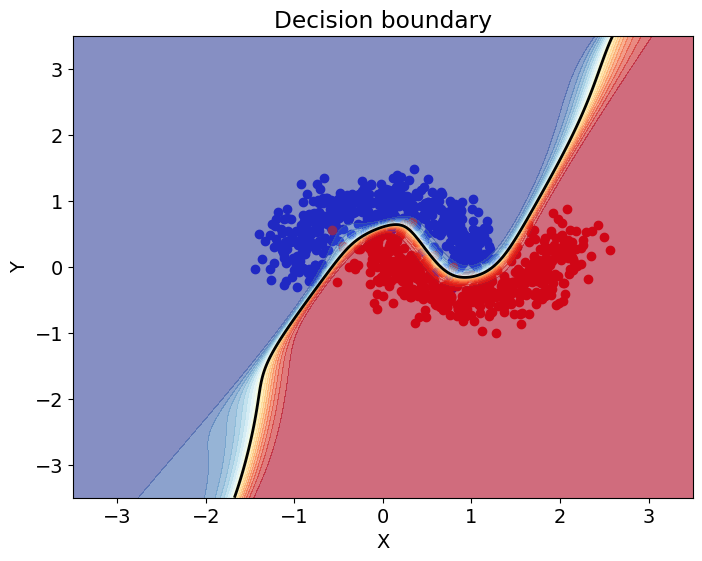

In [177]:
#part b for question 2
from sklearn .datasets import make_moons

X_moons, y_moons = make_moons(n_samples=1000, noise=0.2, random_state=42)

W1_moons, b1_moons, W2_moons, b2_moons, losses_moons = train_network(
    X_moons, y_moons, H=10, lr=1.0, n_epochs=5000
)
class_1_mask = y_moons == 0
class_2_mask = y_moons == 1
fig, axes = plt.subplots()
axes.scatter(X_moons[class_1_mask][:,0],X_moons[class_1_mask][:,1],c='b')
axes.scatter(X_moons[class_2_mask][:,0],X_moons[class_2_mask][:,1],c='r')
axes.set_xlabel('X'); axes.set_ylabel('Y')
axes.set_title('Points for Moons')
xx, yy = np.meshgrid(np.linspace(-3.5, 3.5, 700), np.linspace(-3.5, 3.5, 700))
Z, _ = forward(np.c_[xx.ravel(), yy.ravel()], W1_moons, b1_moons, W2_moons, b2_moons)
Z = Z.reshape(xx.shape)
axes.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
axes.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
axes.set_title('Decision boundary')


In [178]:
#Now compare with linear regression
from sklearn.utils import Bunch
from sklearn.linear_model import LogisticRegression
def plot_decision_boundary(clf, X, y, ax=None, title='', feature_names=None, class_names=None):
    """Plot 2D decision boundary with probability shading."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # create mesh
    margin = 0.5
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    
    # predict probabilities on mesh
    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)
    
    # plot
    cf = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    
    colors = ['tab:blue', 'tab:green']
    for c in np.unique(y):
        sel = y == c
        label = class_names[c] if class_names is not None else f'class {c}'
        ax.scatter(X[sel, 0], X[sel, 1], c=colors[c], edgecolors='k', label=label, alpha=0.8)
    
    if feature_names is not None:
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
    ax.legend()
    ax.set_title(title)
    plt.colorbar(cf, ax=ax, label='P(class 1)')
    return ax

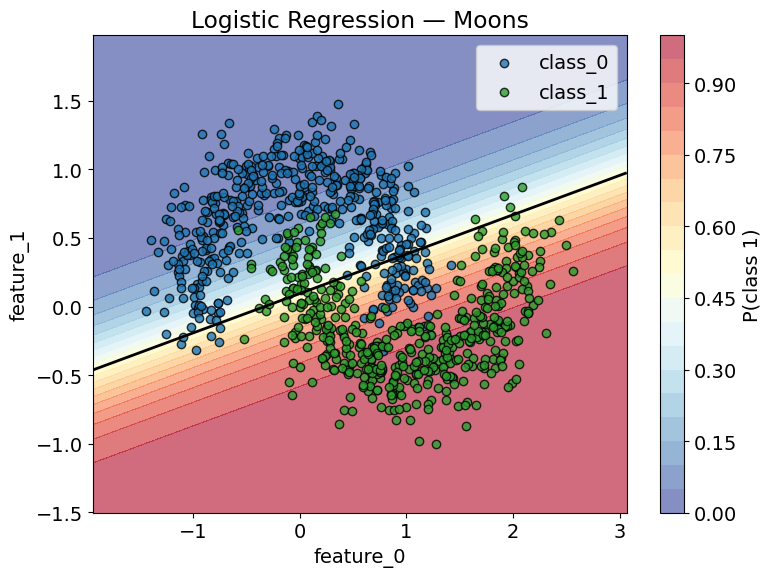

In [179]:
my_dataset = Bunch(
    data=X_moons,
    target=y_moons,
    target_names=np.array(['class_0','class_1']),
    feature_names=['feature_0','feature_1'],
    DESCR="2D Gaussian dataset"
    )
clf_lr = LogisticRegression()
clf_lr.fit(X_moons, y_moons)
plot_decision_boundary(
    clf_lr, X_moons, y_moons,
    title='Logistic Regression — Moons',
    feature_names= my_dataset.feature_names[:2],
    class_names=list(my_dataset.target_names[:2])
    )
plt.tight_layout()
plt.show()

In [180]:
print(X_moons.shape)

print(f"Accuracy = {clf_lr.score(X_moons, y_moons):.2%}")
#As we can see the accuracy is much lower than the trained model of 97.7%. Over ten points difference.

(1000, 2)
Accuracy = 86.80%


#2.C Derivation of DERIVATES for hidden layer
$[(x, y), (x_i, y_i)]$

$$ \mathcal{L} = -\frac{1}{N} \sum_{n=1}^{N} [y_n \log(\hat{y}_n) + (1 - y_n) \log(1 - \hat{y}_n)] $$

$$ \hat{y} = \sigma(\overbrace{W_3 h_2 + b_3}^{z_3}) $$
$$ h_2 = \sigma(\overbrace{W_2 h_1 + b_2}^{z_2}) $$
$$ h_1 = \tanh(\overbrace{W_1 x + b_1}^{z_1}) $$

<br>

$$ \frac{\partial \hat{y}}{\partial W_3} = \frac{\partial \hat{y}}{\partial z_3} \frac{\partial z_3}{\partial W_3} = \sigma(z_3)(1 - \sigma(z_3)) h_2 = \hat{y}(1 - \hat{y}) h_2 $$

$$ \frac{\partial \mathcal{L}}{\partial W_3} = -\frac{1}{N} \sum_{n=1}^{N} \left[ y_n \frac{\frac{\partial \hat{y}}{\partial W_3}}{\hat{y}_n} - (1 - y_n) \frac{\frac{\partial \hat{y}}{\partial W_3}}{1 - \hat{y}_n} \right] $$

$$ \frac{\partial \mathcal{L}}{\partial W_3} = -\frac{1}{N} \sum_{n=1}^{N} [y h_2 (1 - \hat{y}) - (1 - y_n) \hat{y} h_2] $$
$$ = -\frac{h_2}{N} \sum [y - \hat{y}y - \hat{y} + \hat{y}_ny] = \frac{h_2}{N} \sum \hat{y} - y_n $$

$$ \delta_n^3 = \hat{y}_n - y_n \implies \boxed{\frac{\partial \mathcal{L}}{\partial W_3} = \frac{h_2}{N} \sum_n \delta_n^3} $$

$$ \frac{\partial \hat{y}}{\partial b_3} = \frac{\partial \hat{y}}{\partial z_3} \frac{\partial z_3}{\partial b_3} = \hat{y}(1 - \hat{y})$$
<br>
$$ \implies \text {is similar to } W_3 \text {but no } h_2$$
<br>
$$ \boxed{\frac{\partial \mathcal{L}}{\partial b_3} = \frac{1}{N} \sum_n \delta_n^3} $$

<br>
<br>

$$ \frac{\partial \hat{y}}{\partial W_2} = \frac{\partial \hat{y}}{\partial W_2} = \frac{\partial \hat{y}}{\partial z_3} \frac{\partial z_3}{\partial h_2} = \frac{\partial \hat{y}}{\partial z_3} \frac{\partial z_3}{\partial h_2} \frac{\partial h_2}{\partial W_2} = \frac{\partial \hat{y}}{\partial z_3} \frac{\partial z_3}{\partial h_2} \frac{\partial h_2}{\partial z_2} \frac{\partial z_2}{\partial W_2}$$
$$ \frac{\partial \hat{y}}{\partial W_2} = \hat{y}(1 - \hat{y}) W_3 h_2(1 - h_2) h_1 $$

<br>
<br>

$$ \frac{\partial \mathcal{L}}{\partial W_2} = -\frac{1}{N} \sum_{n=1}^{N} [\hat{y}(1 - \hat{y}) W_3 h_2(1 - h_2) h_1 - (1 - y_n) \hat{y} W_3 h_2 (1 - h_2) h_1] = \frac{1}{N} \sum_{n=1}^{N} [\hat{y}_n - y_n] W_3 h_2(1 - h_2) h_1 $$

$${\frac{\partial \mathcal{L}}{\partial W_2} = \frac{1}{N} \sum_{n=1}^{N} \underbrace {\delta^3 W_3 h_2 (1 - h_2)}_{\delta^2} h_1} = \boxed{\frac{\partial \mathcal{L}}{\partial W_2} = \frac{1}{N} \sum_{n=1}^{N} \delta^2 h_1}$$

---
Page 2

<!-- $$ \delta^2 = \underbrace{[\hat{y}_n - y_n] W_3}_{\delta^3 W_3} h_2(1 - h_2) \implies  $$ -->

$$ \frac{\partial \hat{y}}{\partial b_2} = \frac{\partial \hat{y}}{\partial z_3} \frac{\partial z_3}{\partial h_2} \frac{\partial h_2}{\partial z_2} \frac{\partial z_2}{\partial b_2} = \hat{y}(1 - \hat{y}) W_3 h_2(1 - h_2) (1) $$

$$ \boxed{\frac{\partial \mathcal{L}}{\partial b_2} = \frac{1}{N} \sum_{n=1}^{N} \delta_n^2} $$

----working on it----

$$\frac{\partial \hat{z}}{\partial b_2} = \frac{\partial \hat{y}}{\partial z_3} \frac{\partial z_3}{\partial h_2} \frac{\partial h_2}{\partial z_2} \frac{\partial z_2}{\partial b_2} = \hat{y} (1 - \hat{y}) W_3 h_2 (1 - h_2)(1)$$

$$\frac{\partial \mathcal{L}}{\partial W_2} = \frac{1}{N} \sum_{n=1}^{N} [\hat{y}_n - y_n] W_3 h_2 (1 - h_2) = \frac{1}{N} \sum_{n=1}^{N} \delta^2$$

<br>

$$ \frac{\partial \hat{y}}{\partial W_1} = \frac{\partial \hat{y}}{\partial z_3} \frac{\partial z_3}{\partial h_2} \frac{\partial h_2}{\partial z_2} \frac{\partial z_2}{\partial h_1} \frac{\partial h_1}{\partial z_1} \frac{\partial z_1}{\partial W_1} $$
$$ \frac{\partial \hat{y}}{\partial W_1} = \hat{y}(1 - \hat{y}) W_3 h_2(1 - h_2) W_2 (1 - h_1^2) X $$

$$ \frac{\partial \mathcal{L}}{\partial W_1} = \frac{1}{N} \sum_{n=1}^{N} \underbrace{[\hat{y}_n - y_n] W_3 h_2 (1 - h_2) W_2 (1 - h_1^2)}_{\text{delta 1}} X $$

$$ \frac{\partial \mathcal{L}}{\partial W_1} = \frac{1}{N} \sum_{n=1}^{N} \underbrace{\delta^2 W_2 (1 - h^2)}_{\delta^1} X = \boxed{\frac{1}{N} \sum_{n=1}^{N} \delta^1 X} $$



$$ \boxed{\frac{\partial \mathcal{L}}{\partial b_1} = \frac{1}{N} \sum_{n=1}^{N} \delta^1} $$

$$ \frac{\partial \hat{y}}{\partial b_1} = \frac{\partial \hat{y}}{\partial z_3} \frac{\partial z_3}{\partial h_2} \frac{\partial h_2}{\partial z_2} \frac{\partial z_2}{\partial h_1} \frac{\partial h_1}{\partial z_1} \underbrace{\frac{\partial z_1}{\partial b_1}}_{(1)} $$

In [181]:
#2.C we need to add a third hidden layer. 

def forward_2HL(X, W1, b1, W2, b2, W3, b3):
    z1 = X @ W1.T + b1
    h1 = tanh_func(z1)
    z2 = h1 @ W2.T + b2
    h2 = sigmoid(z2)
    z3 = h2 @ W3.T + b3
    y_hat = sigmoid(z3)
    return y_hat, h1, h2

#Now we need to update this to have the updated activation function derivate. 
def backward_2HL(X, y, y_hat, h1, h2, W2, W3):
    """Backpropagation for a 2-layer network."""
    N = len(y)
    delta3 = (y_hat - y)
    dW3 = (h2.T @ delta3) / N
    db3 = np.mean(delta3)
    delta2 = np.outer(delta3, W3) * h2 * (1 - h2)
    dW2 = (delta2.T @ h1) / N
    db2 = np.mean(delta2, axis=0)
    delta1 = np.dot(delta2, W2) * (1 - np.square(h1))
    dW1 = (delta1.T @ X) / N
    db1 = np.mean(delta1, axis=0)
    
    return dW1, db1, dW2, db2, dW3, db3

def train_network_2HL(X, y, H=[10,5], lr=0.5, n_epochs=2000, verbose=True, ndiv=500):
    #Need hidden layer size of [10,5] on top of the moon data. So H = [10,5] here. 
    N, D = X.shape
    rng = np.random.default_rng(0)
    W1 = rng.standard_normal((H[1],D)) * 0.5
    b1 = np.zeros(H[1])
    W2 = rng.standard_normal((H[0],H[1])) * 0.5
    b2 = np.zeros(H[0])
    W3 = rng.standard_normal(H[0]) * 0.5
    b3 = 0.0
    losses = []
    for epoch in range(n_epochs):
        y_hat, h1, h2 = forward_2HL(X, W1, b1, W2, b2, W3, b3)
        loss = binary_cross_entropy(y, y_hat)
        losses.append(loss)
        dW1, db1_g, dW2, db2_g, dW3_g, db3_g = backward_2HL(X, y, y_hat, h1, h2, W2, W3)
        W1 -= lr * dW1
        b1 -= lr * db1_g
        W2 -= lr * dW2
        b2 -= lr * db2_g
        if verbose and epoch % ndiv == 0:
            acc = np.mean((y_hat > 0.5).astype(int) == y)
            print(f'  epoch {epoch:5d}  loss = {loss:.4f}  acc = {acc:.2%}')
    return W1, b1, W2, b2, W3, b3, losses


  epoch     0  loss = 0.6917  acc = 50.60%
  epoch   500  loss = 0.3240  acc = 86.70%
  epoch  1000  loss = 0.3185  acc = 86.90%
  epoch  1500  loss = 0.2606  acc = 90.50%
  epoch  2000  loss = 0.1665  acc = 96.80%
  epoch  2500  loss = 0.1525  acc = 96.90%
  epoch  3000  loss = 0.1464  acc = 97.20%
  epoch  3500  loss = 0.1429  acc = 97.40%
  epoch  4000  loss = 0.1405  acc = 97.50%
  epoch  4500  loss = 0.1387  acc = 97.50%


Text(0.5, 1.0, 'Decision boundary')

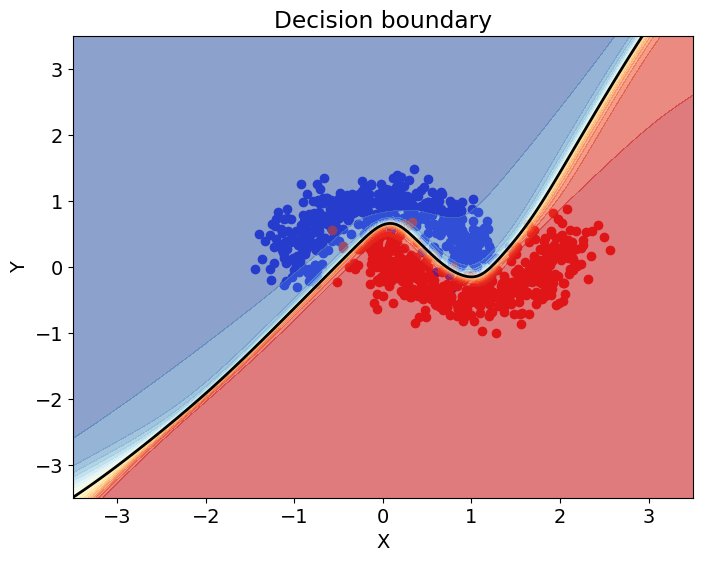

In [182]:
#2.c
W1_2HL_moons, b1_2HL_moons, W2_2HL_moons, b2_2HL_moons, W3_2HL_moons, b3_2HL_moons, losses_2HL_moons = train_network_2HL(
    X_moons, y_moons, H=[10,5], lr=1.0, n_epochs=5000
)

fig, axes = plt.subplots()
axes.scatter(X_moons[class_1_mask][:,0],X_moons[class_1_mask][:,1],c='b')
axes.scatter(X_moons[class_2_mask][:,0],X_moons[class_2_mask][:,1],c='r')
axes.set_xlabel('X'); axes.set_ylabel('Y')
axes.set_title('Points for Moons')
xx, yy = np.meshgrid(np.linspace(-3.5, 3.5, 700), np.linspace(-3.5, 3.5, 700))
Z, h1_moons, h2_moons = forward_2HL(np.c_[xx.ravel(), yy.ravel()], W1_2HL_moons, b1_2HL_moons, W2_2HL_moons, b2_2HL_moons, W3_2HL_moons, b3_2HL_moons)
Z = Z.reshape(xx.shape)
axes.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
axes.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
axes.set_title('Decision boundary')

2.D 
The hardest part about implementing adding a new layer was figuring out what the shapes of W1-W3, b1-b3 should be, and how they should be multiplied together. It took A LOT of trial and error figuring out which things needed needed what kind of inner or outer product even after we got a bunch of shapes that worked for the forward pass. It took even more time trying to get the backwards pass working because of this. Although, deriving what the form for each W and b by hand was not fun. We got a lot of errors during this process. So pytorch is much better by not having to deal with this crap.

Here's one of the errors we got that we both found quite humorous. I hope you enjoy:

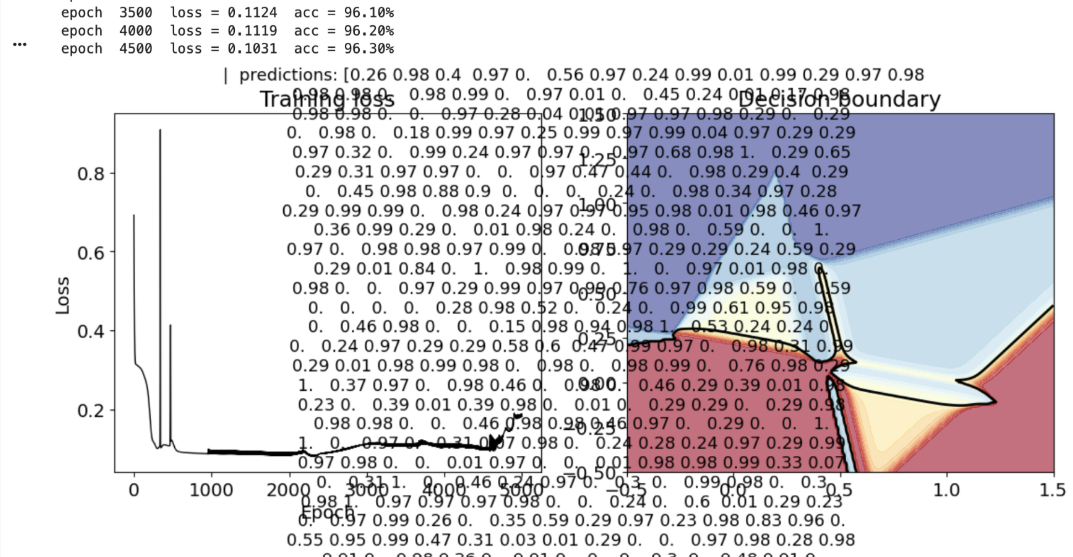

In [15]:
# Question 3
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
mnist_train = datasets.MNIST('./data', train=True,
                             download=True, transform=transform)
mnist_test = datasets.MNIST('./data', train=False,
                            transform=transform)

#For PyTorch training:
from torch.utils.data import DataLoader
train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=1000, shuffle=False)

#For Sklearn (logistic regression), flatten to numpy:
X_train_np = mnist_train.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_train_np = mnist_train.targets.numpy()
X_test_np = mnist_test.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_test_np = mnist_test.targets.numpy()


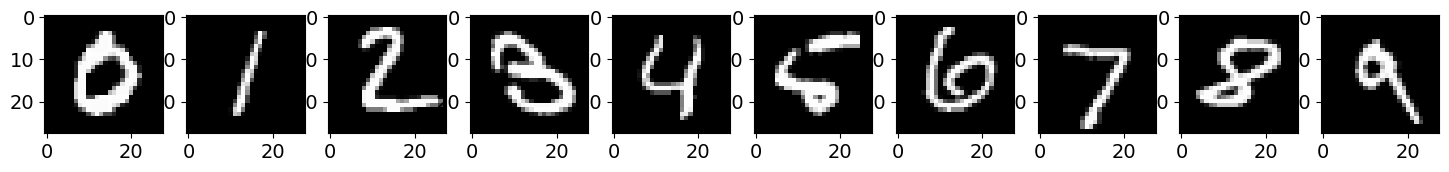

In [16]:
#3.A.a
fig, axes = plt.subplots(1,10,figsize=(18, 5))
depths = np.unique(y_train_np)
for i in depths:
    mask = y_test_np == i
    axes[i].imshow((X_test_np[mask][0].reshape(28,28)).squeeze(), cmap='gray')
plt.show()
    

##fig, axes = plt.subplots()
#plt.imshow((X_test_np[0].reshape(28,28)).squeeze(), cmap='gray')
#plt.show()


In [17]:
#3.A.b
from sklearn.metrics import confusion_matrix

clf_np = LogisticRegression()
clf_np.fit(X_train_np, y_train_np)

test_pred = clf_np.predict(X_test_np)
cm = confusion_matrix(y_test_np, test_pred)
print('accuracy',clf_np.score(X_test_np, y_test_np))
print('confusion matrix')
print(cm)

accuracy 0.9256
confusion matrix
[[ 959    0    0    3    1    7    5    4    1    0]
 [   0 1112    4    2    0    2    3    2   10    0]
 [   6    9  928   16    8    4   15    7   35    4]
 [   4    1   17  921    0   23    4   11   23    6]
 [   1    1    7    4  914    0   10    4   10   31]
 [  10    2    3   37    8  779   14    5   29    5]
 [   9    3    7    3    8   15  910    2    1    0]
 [   1    9   23    6    7    1    0  950    2   29]
 [   9   10    8   26    8   26   12    7  857   11]
 [   9    8    0   11   23    6    0   19    7  926]]


The most commonly confused number pairs appear to be 3 and 5, 2 and 8, 4 and 9. Which from the squiggle style isn't that surprising. 

In [18]:
#3.A.c
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#Need to make this 10 output neurons, 128 neurons for hidden layer, and ReLU activation function
class FlexNet(nn.Module):
    """
    Flexible feedforward network.
    
    hidden_sizes: list of ints, e.g. [32, 16] for 2 hidden layers
    activation: 'sigmoid', 'relu', or 'tanh'
    """
    def __init__(self, input_dim, hidden_sizes, activation='relu'):
        super().__init__()
        
        act_map = {'sigmoid': nn.Sigmoid, 'relu': nn.ReLU, 'tanh': nn.Tanh}
        act_fn = act_map[activation]
        
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(act_fn())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 10))
        #layers.append(nn.Sigmoid())  # output probability
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze(-1)


X_tr_np = torch.tensor(X_train_np, dtype=torch.float32).to(device)
y_tr_np = torch.tensor(y_train_np, dtype=torch.float32).to(device)
X_te_np = torch.tensor(X_test_np, dtype=torch.float32).to(device)
y_te_np = torch.tensor(y_test_np, dtype=torch.float32).to(device)



In [19]:
class SimpleNet(nn.Module):
    """A simple feedforward network with one hidden layer."""
    
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, 10)
    
    def forward(self, x):
        h = self.hidden(x)   # hidden layer + activation
        out = self.output(h)  # output layer + sigmoid
        return out.squeeze(-1)               # shape (N,)

In [38]:
def train_pytorch(model, train_loader, test_loader, lr=0.01, n_epochs=100, verbose=True):
    """
    Train a PyTorch model and track train/test loss.
    """
    criterion = nn.CrossEntropyLoss()  # binary cross-entropy — same loss as Day 2
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    test_losses = []
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        
        for X_batch, y_batch in train_loader:

            X_batch = (X_batch.reshape(-1,784)).to(device)
            y_batch = y_batch.to(device)

            # forward
            y_pred = model(X_batch)
            
            
            loss = criterion(y_pred, y_batch)
            
            # backward (automatic!)
            optimizer.zero_grad()
            loss.backward()
            
            # update
            optimizer.step()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        train_losses.append(epoch_loss / n_batches)
        
        # evaluate on test set
        model.eval()
        with torch.no_grad():
            for Xb, yb in test_loader:
                X_test, y_test = (Xb.reshape(-1,784)).to(device), yb.to(device)
                y_pred_test = model(X_test)
                test_loss = criterion(y_pred_test, y_test).item()
                test_losses.append(test_loss)
                
        if verbose and epoch % 5 == 0:
            acc = (np.mean(((torch.argmax(y_pred_test,axis=-1)) == y_test).numpy())).item()
            print(f"  epoch {epoch:4d}  train_loss={train_losses[-1]:.4f}  "
                  f"test_loss={test_loss:.4f}  test_acc={acc:.2%}")
        
    return train_losses, test_losses

In [27]:
net_np = FlexNet(784, [128], activation='relu').to(device)
#net_np = SimpleNet(input_dim=784, hidden_dim=128).to(device)

train_losses_np, test_losses_np = train_pytorch(
    net_np, train_loader, test_loader, lr=0.01, n_epochs=20
)

# train_losses_np, test_losses_np = train_pytorch(
#     net_np, train_loader, test_loader, lr=0.001, n_epochs=20
# )

  epoch    0  train_loss=0.2529  test_loss=0.2020  test_acc=94.00%
  epoch    5  train_loss=0.1249  test_loss=0.2338  test_acc=96.50%
  epoch   10  train_loss=0.1074  test_loss=0.2873  test_acc=96.80%
  epoch   15  train_loss=0.1019  test_loss=0.3782  test_acc=95.40%


The neural network did better than the linear regession by a couple of percentage points (92.5% vs 96.8%). So it did better, although the linear regession did surprisingly well at this task. 

In [28]:
def train_pytorch_small(model, train_loader, test_loader, lr=0.01, n_epochs=100, verbose=True):
    """
    Train a PyTorch model and track train/test loss.
    """
    criterion = nn.CrossEntropyLoss()  # binary cross-entropy — same loss as Day 2
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    test_losses = []
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0

        for X_batch, y_batch in train_loader:
            #Added in this to break out of this for loop after 79 batches, or above 10,000 data points. 
            if(n_batches > 79): break
            X_batch = (X_batch.reshape(-1,784)).to(device)
            y_batch = y_batch.to(device)

            # forward
            y_pred = model(X_batch)
            
            loss = criterion(y_pred, y_batch)
            
            # backward (automatic!)
            optimizer.zero_grad()
            loss.backward()
            
            # update
            optimizer.step()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        train_losses.append(epoch_loss / n_batches)
        
        # evaluate on test set
        model.eval()
        with torch.no_grad():
            for Xb, yb in test_loader:
                X_test, y_test = (Xb.reshape(-1,784)).to(device), yb.to(device)
                y_pred_test = model(X_test)
                test_loss = criterion(y_pred_test, y_test).item()
                test_losses.append(test_loss)
                
        if verbose and epoch % 5 == 0:
            acc = (np.mean(((torch.argmax(y_pred_test,axis=-1)) == y_test).numpy())).item()
            print(f"  epoch {epoch:4d}  train_loss={train_losses[-1]:.4f}  "
                  f"test_loss={test_loss:.4f}  test_acc={acc:.2%}")
        
    return train_losses, test_losses

In [23]:
#3.B.d 

train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=1000, shuffle=False)

#Deep network

net_deep_np = FlexNet(784, [128, 64, 32], activation='relu').to(device)
train_losses_deep_np, test_losses_deep_np = train_pytorch_small(
    net_deep_np, train_loader, test_loader, lr=0.01, n_epochs=20
)



  epoch    0  train_loss=0.5705  test_loss=0.2483  test_acc=92.40%
  epoch    5  train_loss=0.1604  test_loss=0.1689  test_acc=95.50%
  epoch   10  train_loss=0.1336  test_loss=0.2204  test_acc=94.30%
  epoch   15  train_loss=0.1133  test_loss=0.1471  test_acc=95.70%


In [30]:
#Narrow

net_narrow_np = FlexNet(784, [32], activation='relu').to(device)
train_losses_narrow_np, test_losses_narrow_np = train_pytorch_small(
    net_narrow_np, train_loader, test_loader, lr=0.001, n_epochs=20
)


  epoch    0  train_loss=0.8884  test_loss=0.3971  test_acc=89.30%
  epoch    5  train_loss=0.2503  test_loss=0.2584  test_acc=92.80%
  epoch   10  train_loss=0.2006  test_loss=0.2045  test_acc=94.10%
  epoch   15  train_loss=0.1632  test_loss=0.1905  test_acc=94.50%


In [24]:
#Wide

net_wide_np = FlexNet(784, [256], activation='relu').to(device)
train_losses_wide_np, test_losses_wide_np = train_pytorch_small(
    net_wide_np, train_loader, test_loader, lr=0.001, n_epochs=20
)


  epoch    0  train_loss=0.5542  test_loss=0.3239  test_acc=90.10%
  epoch    5  train_loss=0.1340  test_loss=0.1304  test_acc=95.90%
  epoch   10  train_loss=0.0864  test_loss=0.1086  test_acc=96.90%
  epoch   15  train_loss=0.0634  test_loss=0.0989  test_acc=96.90%


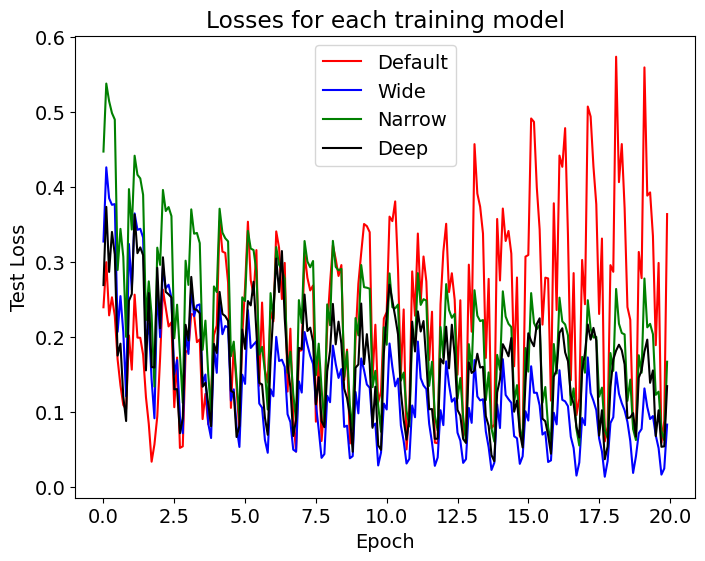

In [31]:
#3.d. making the plots for the loss functions.
import awkward as ak

fig, axes = plt.subplots()
epoch_number = np.arange(len(test_losses_np)) / 10
plt.plot(epoch_number, np.array(test_losses_np), c='r', label='Default')
plt.plot(epoch_number, np.array(test_losses_wide_np), c='b', label='Wide')
plt.plot(epoch_number, np.array(test_losses_narrow_np), c='g', label='Narrow')
plt.plot(epoch_number, np.array(test_losses_deep_np), c='k', label='Deep')
axes.set_xlabel('Epoch'); axes.set_ylabel('Test Loss')
axes.set_title('Losses for each training model')
plt.legend()

3.d 

There is a clear winner here. The Wide network had the best accuracy achieving nearly 97% accuracy, and it had consistently the lowest testing loss. 

  epoch    0  train_loss=0.0000  test_loss=0.3224  test_acc=96.30%
  epoch    5  train_loss=0.0000  test_loss=0.3478  test_acc=96.30%
  epoch   10  train_loss=0.0000  test_loss=0.3536  test_acc=96.30%
  epoch   15  train_loss=0.0000  test_loss=0.3545  test_acc=96.20%


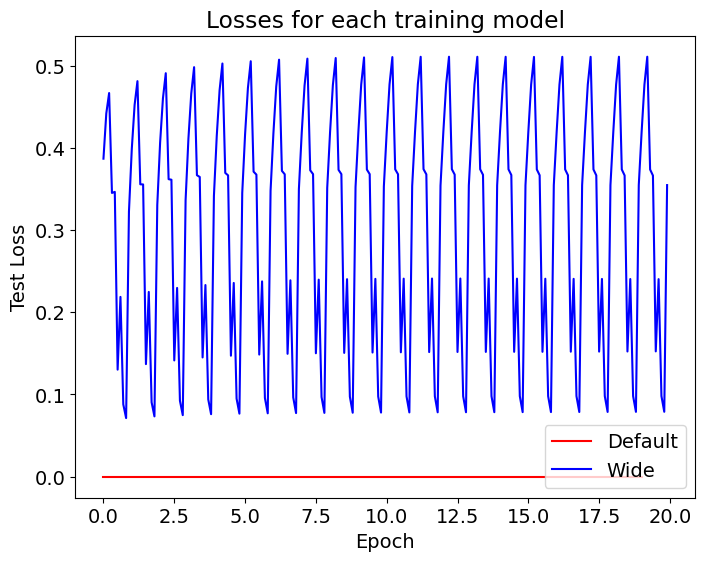

In [36]:
#3.e
train_loader_tiny = train_loader
train_loader_tiny.dataset.data = train_loader_tiny.dataset.data[0:500]


net_deep_2 = FlexNet(784, [128, 64, 32], activation='relu').to(device)
train_losses_deep_np2, test_losses_deep_np2 = train_pytorch(
    net_deep_np, train_loader_tiny, test_loader, lr=0.001, n_epochs=20
)

epoch_number_train = np.arange(len(train_losses_deep_np2))
epoch_number_test = np.arange(len(test_losses_deep_np2)) / 10
fig, axes = plt.subplots()
plt.plot(epoch_number_train, np.array(train_losses_deep_np2), c='r', label='Default')
plt.plot(epoch_number_test, np.array(test_losses_deep_np2), c='b', label='Wide')
axes.set_xlabel('Epoch'); axes.set_ylabel('Test Loss')
axes.set_title('Losses for each training model')
plt.legend()

3.e

So, there's definitely overfitting goig on as we have zero loss almost immediately, with testing loss increasing (sinusoidally for some reason) from the first epoch. 

In [40]:
def train_pytorch_full(model, train_loader, test_loader, lr=0.01, n_epochs=100, verbose=True):
    """
    Train a PyTorch model and track train/test loss.
    """
    criterion = nn.CrossEntropyLoss()  # binary cross-entropy — same loss as Day 2
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    test_losses = []
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        
        for X_batch, y_batch in train_loader:

            X_batch = (X_batch.reshape(-1,784)).to(device)
            y_batch = y_batch.to(device)

            # forward
            y_pred = model(X_batch)
            
            
            loss = criterion(y_pred, y_batch)
            
            # backward (automatic!)
            optimizer.zero_grad()
            loss.backward()
            
            # update
            optimizer.step()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        train_losses.append(epoch_loss / n_batches)
        
        # evaluate on test set
        model.eval()
        with torch.no_grad():
            for Xb, yb in test_loader:
                X_test, y_test = (Xb.reshape(-1,784)).to(device), yb.to(device)
                y_pred_test = model(X_test)
                test_loss = criterion(y_pred_test, y_test).item()
                test_losses.append(test_loss)
                
        if verbose and epoch % 1 == 0:
            acc = (np.mean(((torch.argmax(y_pred_test,axis=-1)) == y_test).numpy())).item()
            print(f"  epoch {epoch:4d}  train_loss={train_losses[-1]:.4f}  "
                  f"test_loss={test_loss:.4f}  test_acc={acc:.2%}")
        
    return train_losses, test_losses

train_loader_small = train_loader
train_loader_small.dataset.data = train_loader_small.dataset.data[0:1000]

net_np = FlexNet(784, [128], activation='relu').to(device)
#net_np = SimpleNet(input_dim=784, hidden_dim=128).to(device)

train_losses_np, test_losses_np = train_pytorch_full(
    net_np, train_loader_small, test_loader, lr=0.01, n_epochs=20
)

  epoch    0  train_loss=1.6962  test_loss=1.1492  test_acc=63.40%
  epoch    1  train_loss=0.6731  test_loss=1.0444  test_acc=67.10%
  epoch    2  train_loss=0.4185  test_loss=0.6528  test_acc=81.60%
  epoch    3  train_loss=0.2662  test_loss=0.6788  test_acc=82.40%
  epoch    4  train_loss=0.1663  test_loss=0.6159  test_acc=83.20%
  epoch    5  train_loss=0.1026  test_loss=0.5814  test_acc=85.10%
  epoch    6  train_loss=0.0608  test_loss=0.6105  test_acc=84.30%
  epoch    7  train_loss=0.0374  test_loss=0.6985  test_acc=83.20%
  epoch    8  train_loss=0.0247  test_loss=0.7395  test_acc=83.10%
  epoch    9  train_loss=0.0143  test_loss=0.7278  test_acc=83.60%
  epoch   10  train_loss=0.0092  test_loss=0.7277  test_acc=83.70%
  epoch   11  train_loss=0.0065  test_loss=0.7399  test_acc=84.90%
  epoch   12  train_loss=0.0046  test_loss=0.7494  test_acc=85.00%
  epoch   13  train_loss=0.0036  test_loss=0.7602  test_acc=84.70%
  epoch   14  train_loss=0.0027  test_loss=0.7704  test_acc=84

3.f

So judging from the list out above, the minimum of the validation set is at epoch 5, with a accuracy of 85.10%, compared to 84.50% at 20 epochs. So really we didn't need to go to 20 epochs at all for this. 

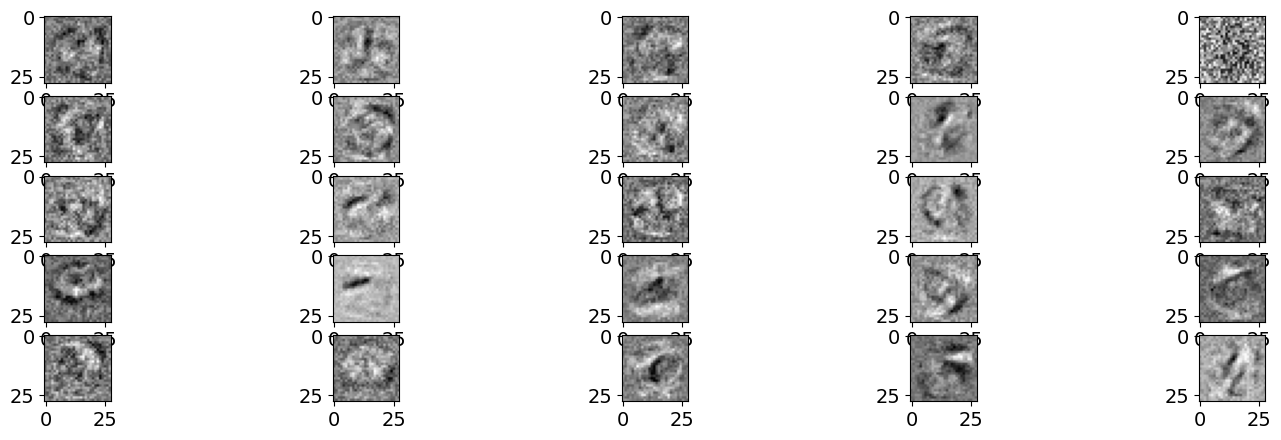

In [71]:
#3.g.
#Getting the parameters from the wide model, since it worked the best here.
#I only plotted the first ten since there's 256 ones to choose from. So you know... I didn't want to plot every single one of them. 
test = list(net_wide_np.parameters())
W1 = (test[0].reshape(-1,28,28)).to(device).detach().numpy()

fig, axes = plt.subplots(5,5,figsize=(18, 5))
depths = np.arange(5)
for i in depths:
    for j in depths:
        axes[i,j].imshow(W1[i*5+j].squeeze(), cmap='gray')
plt.show()


3.g 

I think the one four right and three down from the top left kinda looks like the top half of a eight, 2 right and four down looks like a stroke from either a seven or maybe a one. 2 down and 2 right as well as four right and 0 down looks like zeroes almost. Although some of these are just noise, like five right and zero down. 

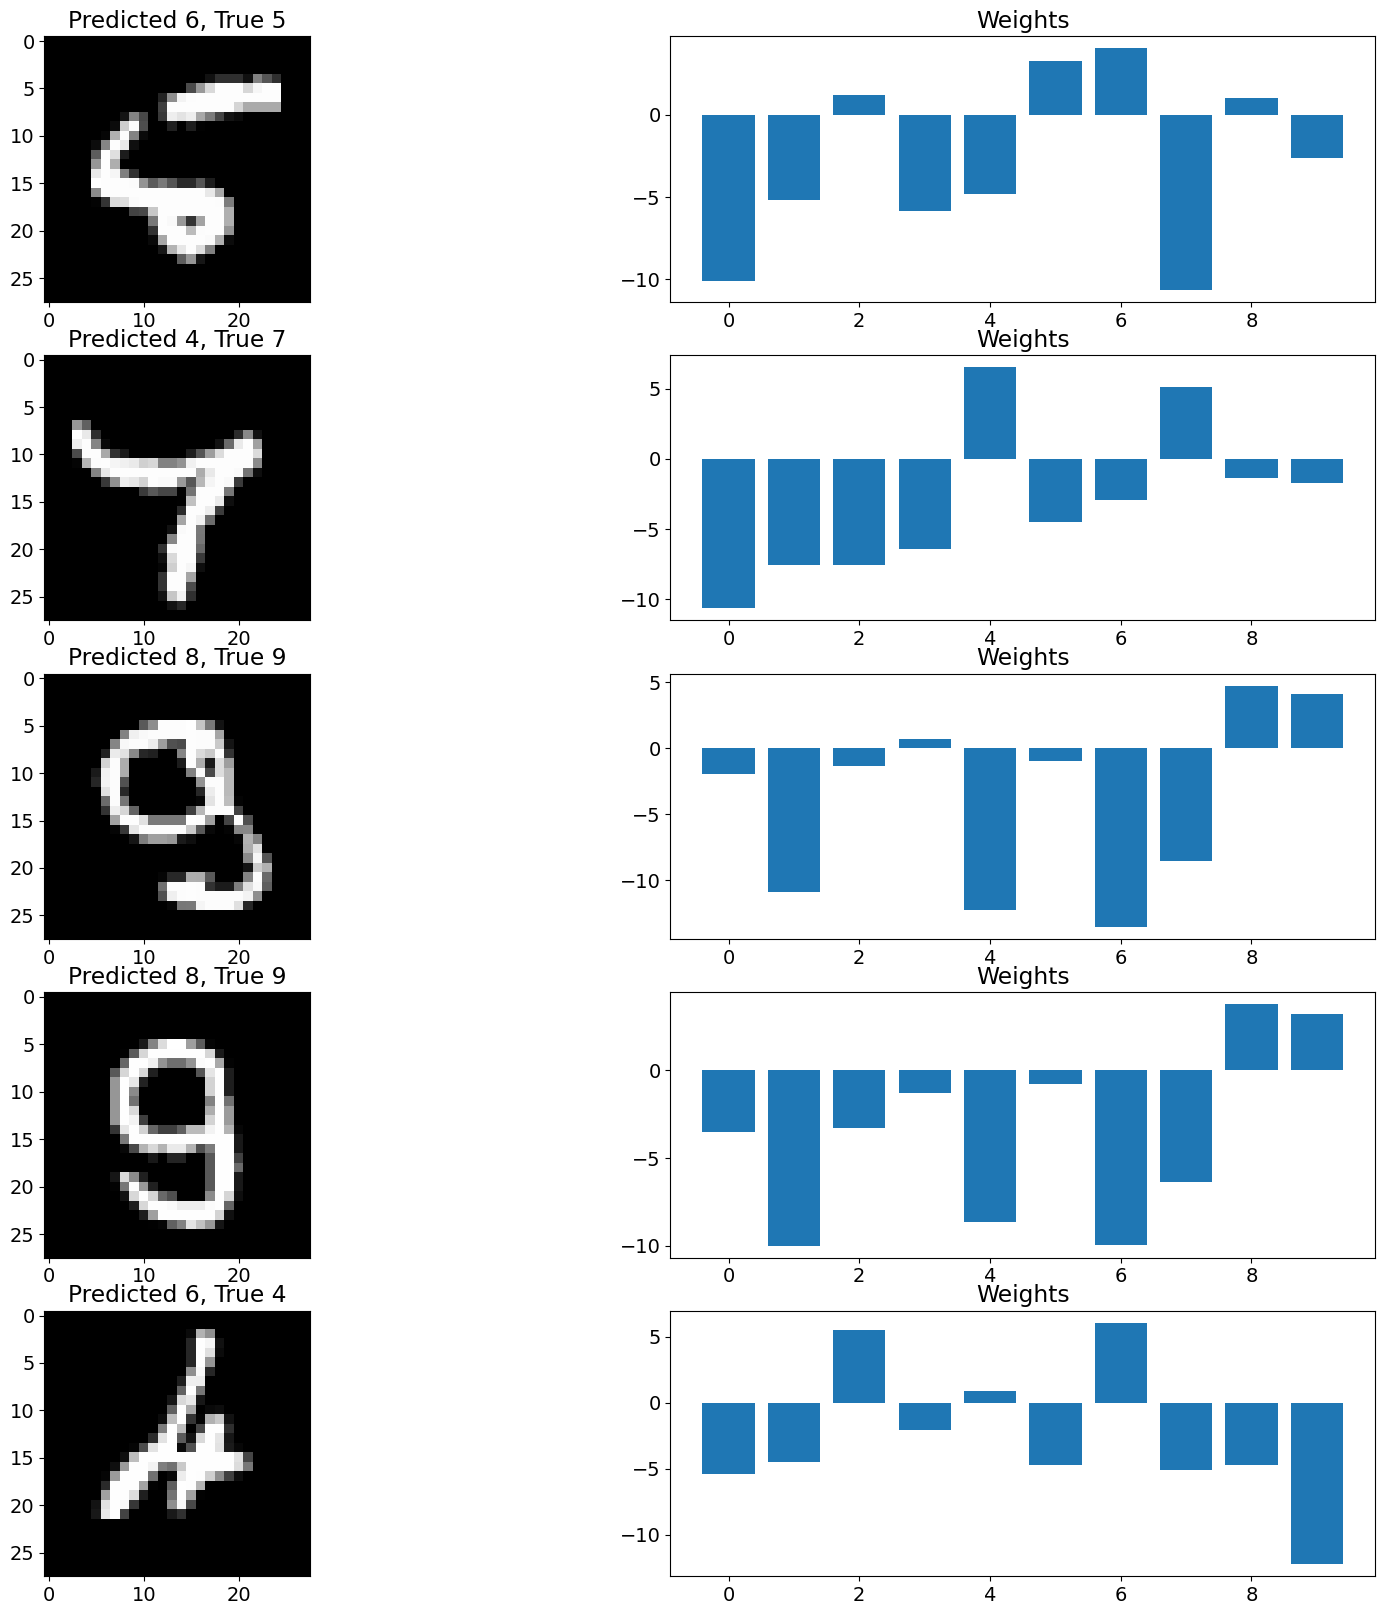

In [93]:
#3.h
misfile_list_X = []
misfile_list_Y = []
true_list_Y = []

for Xb, yb in test_loader:
    X_test, y_test = (Xb.reshape(-1,784)).to(device), yb.to(device)
    y_pred_test = net_wide_np(X_test)
    mask = y_test != (torch.argmax(y_pred_test,axis=-1))
    if(np.sum(mask.numpy()) == 0): continue
    misfile_list_X.append(X_test[mask])
    true_list_Y.append(y_test[mask])
    misfile_list_Y.append(y_pred_test[mask])
    break

fig, axes = plt.subplots(5,2,figsize=(20, 20))
depths = np.arange(5)
x_bar = np.arange(10)
for i in depths:

    axes[i,0].set_title(f'Predicted {torch.argmax(misfile_list_Y[0][i])}, True {true_list_Y[0][i]}')
    axes[i,0].imshow(((misfile_list_X[0][i].reshape(-1,28,28)).to(device).detach().numpy()).squeeze(), cmap='gray')
    axes[i,1].set_title('Weights')
    axes[i,1].bar(x_bar, (misfile_list_Y[0][i]).detach().numpy())
plt.show()

3.h

Yeah, some of these aren't very excusable like the 9 being confused as an 8. But that very last one, I would've thought that was just an H, rather than a 4. I can kinda see the 6, and same for the first one. Some of these are very hard to read, so I don't blame the network for missing those examples.

Loss: 1.8541
Loss: 0.8299
Loss: 0.8294
Loss: 0.8275
Loss: 0.8258
Loss: 0.8250


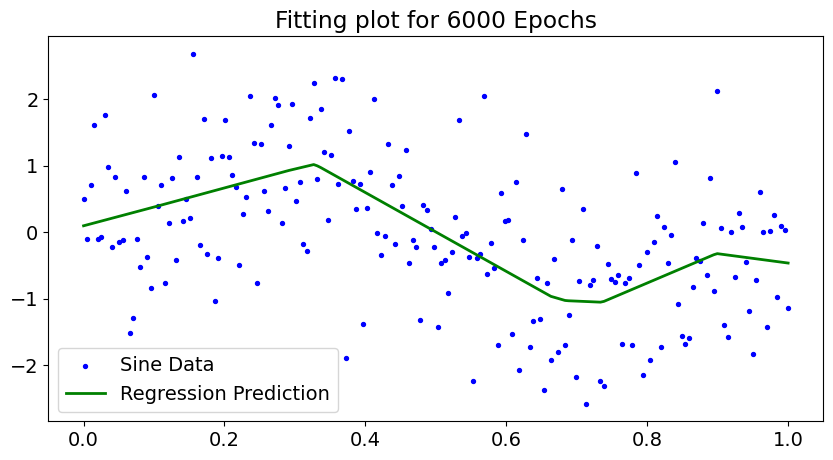

In [63]:
#Question 4
import numpy as np
import torch.nn as nn

class RegNet(nn.Module):
    def __init__(self, H):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, H), nn.ReLU(), nn.Linear(H, 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)

np.random.seed(42)
X_4 = np.linspace(0, 1, 200).reshape(-1, 1)
y_4 = np.sin(2 * np.pi * X_4).ravel() + np.random.randn(200)

X_tensor = torch.tensor(X_4, dtype = torch.float32)
y_tensor = torch.tensor(y_4, dtype = torch.float32)

import torch.optim as optim

R_regression = RegNet(128)
loss_function = nn.MSELoss()

# Adam with lr ~ 0.005
optimo = optim.Adam(R_regression.parameters(), lr = 0.005)

epochss = 6000
losses = []

for epoch in range(epochss):
    y_pred = R_regression(X_tensor)
    loss = loss_function(y_pred, y_tensor)
    losses.append(loss.item())

    optimo.zero_grad()
    loss.backward()
    optimo.step()

    # ensure to run to the last bit.
    if epoch % 1000 == 0:
        print(f'Loss: {loss.item():.4f}')





# plotting
R_regression.eval()
with torch.no_grad():
    predicted = R_regression(X_tensor).numpy()

plt.figure(figsize=(10, 5))
plt.scatter(X_4, y_4, label='Sine Data', alpha=1, c = 'blue', s = 8)
plt.plot(X_4, predicted, color='green', label='Regression Prediction', linewidth=2)
plt.title(f'Fitting plot for {epochss} Epochs')
plt.legend()
plt.show()

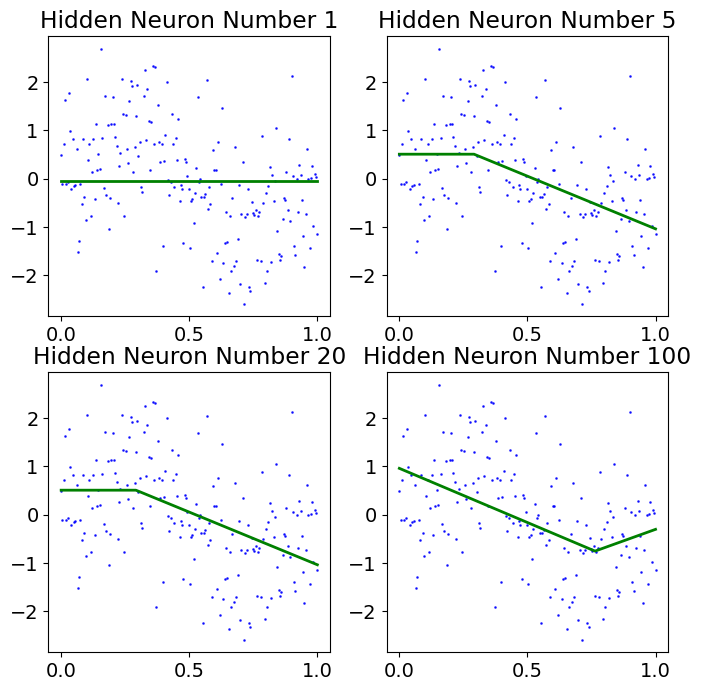

In [69]:
H = [1, 5, 20, 100]
regression_list = []
# loss_function = nn.MSELoss()

for h in range(len(H)):
    # print('start')
    H_regression = RegNet(h)
    optimo = optim.Adam(H_regression.parameters(), lr = 0.005)

    for epoch in range(epochss):
        y_pred = H_regression(X_tensor)
        loss = loss_function(y_pred, y_tensor)
        losses.append(loss.item())

        optimo.zero_grad()
        loss.backward()
        optimo.step()

    regression_list.append(H_regression)





fig, axes = plt.subplots(2, 2, figsize = (8, 8))

#print(f'Loss: {loss.item():.4f}')

axes = axes.flatten()

for i, h in enumerate(H):
    H_regression = regression_list[i]
    H_regression.eval()
    with torch.no_grad():
        predicted_multi = H_regression(X_tensor).numpy()
    axes[i].set_title(f"Hidden Neuron Number {H[i]}")
    axes[i].scatter(X_4, y_4, label = "Sine data", c = "blue", s = 0.8, alpha = 0.8)
    axes[i].plot(X_4, predicted_multi, label = f'Regression Prediction for H = {h}', c = 'green', linewidth = 2)
    axes[i].legend

plt.show()

4.b Discussion

The neuron network does not overfit in any case. In truth it underfits, as these fits suck. Probable need more neurons to properly do this. Still, the activation function determines which neuron turns on or off, which means that it can self regulate on how many degrees of freedom the fit has. This allows the neural net to avoid overfitting, as it doesn't use too many neurons than it needs. 
